### LLM

In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


### Tool

In [2]:
from langchain_tavily import TavilySearch

search_web = TavilySearch(max_results=5,
                            search_depth='advanced',
                            include_answers=False,
                            include_raw_content=True)
tools = [search_web]

/media/ultron.legacy/HDD/GitHub/ai-agent-lab/.venv/lib/python3.10/site-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "output_schema" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]
/media/ultron.legacy/HDD/GitHub/ai-agent-lab/.venv/lib/python3.10/site-packages/langchain_tavily/tavily_research.py:97: UserWarning: Field name "stream" in "TavilyResearch" shadows an attribute in parent "BaseTool"
  class TavilyResearch(BaseTool):  # type: ignore[override, override]


### Graph State

In [3]:
from langgraph.graph import MessagesState, StateGraph, START, END

# Graph state is MessagesState

### Nodes

In [4]:
def call_model(state: MessagesState) -> dict:
    llm_with_tool = llm.bind_tools(tools)
    messages = state["messages"]
    response = llm_with_tool.invoke(messages)
    return {'messages': messages + [response]}

In [5]:
def should_continue(state: MessagesState) -> bool:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return True
    return False

### Graph

In [6]:
graph = StateGraph(MessagesState)

### Add nodes

In [7]:
graph.add_node('agent', call_model)

In [8]:
from langchain_tavily import TavilySearch
from langgraph.prebuilt import ToolNode

search_tool = TavilySearch(max_results=5,
                            search_depth='advanced',
                            include_answers=False,
                            include_raw_content=True)
tools = [search_tool]
tool_node = ToolNode(tools=tools)

graph.add_node('tools', tool_node)

### Add edges to connect nodes

In [9]:
graph.add_edge(START, 'agent')

In [10]:
graph.add_conditional_edges('agent', should_continue, {
    True: 'tools',
    False: END})

In [11]:
graph.add_edge('tools', 'agent')

### Compile graph

In [12]:
graph_compiled = graph.compile()

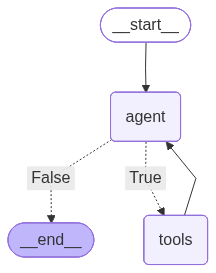

In [13]:
from IPython.display import display, Image

display(Image(graph_compiled.get_graph().draw_mermaid_png()))

### Run the model

In [14]:
output = graph_compiled.invoke(
    {
        "messages": [
            ("user", "is there any recent attack on venezuela?" )
        ]
    }
)
output

{'messages': [HumanMessage(content='is there any recent attack on venezuela?', additional_kwargs={}, response_metadata={}, id='c49b97da-5428-40ad-ab23-7f7898b99232'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"time_range": "month", "topic": "news", "query": "recent attack on Venezuela"}'}, '__gemini_function_call_thought_signatures__': {'d20dc342-d4ab-4919-8c07-854abe488965': 'CqEEAXLI2nz5Ok6b3R8XG9jzf5U2/+HQpTO0ggZtRney2Q3/WTZbvvzoIqWbH6UToIlPOhEuA+MIxjPYWJ+RYVUqYbBQ/71mg06Pp2guk2H28PBQgOcXm2mfYlo1dzu1yPsnu6vy3UQTPGYv1tr8QvBoOSHBvqs8oOA63F6E1OKoZ335WVacXvOWLjKCxBbrg1KRYIKLpiRUN2WV8vSu9wv0RJpc4FetTMJwPFTGXFyE/aOnELwBd0yRlEd1pfREvkV2BXSBlKroyOaNQlglFRl0SA8I/CK72hg6vD1mfs8jszxBah7F3w6OCygQoOKh+zDEu/HTH466Wwbkoy9N7B2qeiXfqzUudSQ4kTPiNt5pToXQQiTEwwr7bERi1TpCEixpfCzEF74sG5Rx007I0t4fzR3qHCDgH2qNcEo3z5VbYdn3KOqRATyuwTfWSERxMFllvTj0++4j0iYTqgUgB0gCwyJtxw4UBzv1JMRaIjWRjVysonD7Q08mmfg9VWgBRHdxdYL5Irhw2lTmqyjC8yd9zcLj//ip4k+mQoYhB4tE17xRj

In [18]:
dict(output['messages'][1])

{'content': '',
 'additional_kwargs': {'function_call': {'name': 'tavily_search',
   'arguments': '{"time_range": "month", "topic": "news", "query": "recent attack on Venezuela"}'},
  '__gemini_function_call_thought_signatures__': {'d20dc342-d4ab-4919-8c07-854abe488965': 'CqEEAXLI2nz5Ok6b3R8XG9jzf5U2/+HQpTO0ggZtRney2Q3/WTZbvvzoIqWbH6UToIlPOhEuA+MIxjPYWJ+RYVUqYbBQ/71mg06Pp2guk2H28PBQgOcXm2mfYlo1dzu1yPsnu6vy3UQTPGYv1tr8QvBoOSHBvqs8oOA63F6E1OKoZ335WVacXvOWLjKCxBbrg1KRYIKLpiRUN2WV8vSu9wv0RJpc4FetTMJwPFTGXFyE/aOnELwBd0yRlEd1pfREvkV2BXSBlKroyOaNQlglFRl0SA8I/CK72hg6vD1mfs8jszxBah7F3w6OCygQoOKh+zDEu/HTH466Wwbkoy9N7B2qeiXfqzUudSQ4kTPiNt5pToXQQiTEwwr7bERi1TpCEixpfCzEF74sG5Rx007I0t4fzR3qHCDgH2qNcEo3z5VbYdn3KOqRATyuwTfWSERxMFllvTj0++4j0iYTqgUgB0gCwyJtxw4UBzv1JMRaIjWRjVysonD7Q08mmfg9VWgBRHdxdYL5Irhw2lTmqyjC8yd9zcLj//ip4k+mQoYhB4tE17xRjVcce/FlzJiUxccPnMh8IighppCWLCz2ncMw2Rf0mhYSLlDbfxBwngXDkQrBjlA8omU+MHbWXFGnm/q0oLyLG65yXKAZ/bPjIJrh887BOIqsVxdOuLAMCruRt+uD3fZ0lt9wEnA/DvZ8DvnxP6lzytBRe54E934IeW/BCs0

In [19]:
output['messages'][1].tool_calls

[{'name': 'tavily_search',
  'args': {'time_range': 'month',
   'topic': 'news',
   'query': 'recent attack on Venezuela'},
  'id': 'd20dc342-d4ab-4919-8c07-854abe488965',
  'type': 'tool_call'}]

In [17]:
from IPython.display import Markdown

Markdown(output['messages'][-1].content[0]['text'])

Yes, there have been recent reports of attacks on Venezuela. In early January 2026, multiple explosions were heard in Caracas, the capital of Venezuela. The Venezuelan government has accused the United States of these attacks, calling them an act of aggression. Colombia's President Gustavo Petro also stated that Caracas was being bombed and called for an emergency UN meeting.

While the U.S. has not confirmed its involvement in the Caracas explosions, it has been increasing pressure on Venezuela and has conducted military strikes on alleged drug trafficking boats in the Caribbean and eastern Pacific.